# 02.8 - Phase 02 Synthesis: The Math of a Model

**Phase:** 02 - Mathematics for ML

**Status:** VERIFIED

---

## 1. What Are We Solving?

This is the **capstone** of Phase 02. We bring together every concept from Units 02.1-02.7 into one coherent project: build a **linear regression model from scratch** using vectors and matrices (02.1, 02.2), train it with **gradient descent** (02.3, 02.4), evaluate it with **probability and statistics** (02.5), reason about its loss with **information theory** (02.6), and reduce its input dimensionality with **eigenvalues/PCA** (02.7).

## 2. Why Does This Matter?

This is the moment where the math stops being abstract and becomes a working model. Every piece of math you learned has a concrete role in this pipeline. Understanding this end-to-end is the foundation for everything that follows in ML.

## 3. Prerequisites

- Units 02.1 through 02.7 (all of Phase 02)
- Phase 01 (Python Foundations)

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- Combine vectors, matrices, gradients, and gradient descent into a working model
- Evaluate a model using statistical measures
- Connect cross-entropy and likelihood to model training
- Use PCA to reduce dimensionality
- See the full math-to-model pipeline

## 5. Mental Model

A model is a function with parameters. The **math** tells us: how to represent data (vectors/matrices), how to measure error (loss), how to find the best parameters (gradient descent), how to quantify uncertainty (probability), and how to simplify the data (PCA). This notebook chains all of these together.


## 6. Step 1: Generate Data (Vectors & Matrices)

We generate a synthetic dataset with several features. The data is a **matrix** `X` (samples x features) and a **vector** `y` (targets).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate a dataset: y = 3*x1 - 2*x2 + 0.5*x3 + noise
n = 200
X = np.random.randn(n, 3)
true_w = np.array([3.0, -2.0, 0.5])
true_b = 1.0
y = X @ true_w + true_b + np.random.randn(n) * 0.5

print(f"X shape (matrix): {X.shape}")
print(f"y shape (vector): {y.shape}")
print(f"True weights: {true_w}, true bias: {true_b}")
print("\nThis is a matrix-vector product: y = X @ w + b + noise")


X shape (matrix): (200, 3)
y shape (vector): (200,)
True weights: [ 3.  -2.   0.5], true bias: 1.0

This is a matrix-vector product: y = X @ w + b + noise


## 7. Step 2: The Normal Equation (Matrix Operations)

From Unit 02.2, the **normal equation** gives the closed-form solution for linear regression:

`w = (X^T X)^-1 X^T y`

This uses matrix multiplication, transpose, and inverse - all from Unit 02.2.


In [2]:
# Normal equation: w = (X^T X)^-1 X^T y
# Add a column of ones for the bias term
X_b = np.hstack([np.ones((n, 1)), X])  # [bias, x1, x2, x3]

w_normal = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
print("Normal equation solution:")
print(f"  bias: {w_normal[0]:.4f} (true {true_b})")
print(f"  w1:   {w_normal[1]:.4f} (true {true_w[0]})")
print(f"  w2:   {w_normal[2]:.4f} (true {true_w[1]})")
print(f"  w3:   {w_normal[3]:.4f} (true {true_w[2]})")
print("\nThe normal equation recovers the true parameters (up to noise).")


Normal equation solution:
  bias: 1.0094 (true 1.0)
  w1:   2.9881 (true 3.0)
  w2:   -1.9538 (true -2.0)
  w3:   0.5593 (true 0.5)

The normal equation recovers the true parameters (up to noise).


## 8. Step 3: Gradient Descent (Derivatives & Gradients)

Now we train the same model with **gradient descent** (Units 02.3, 02.4), computing the gradient of the MSE loss and updating parameters.


In [3]:
# Gradient descent on MSE loss
def mse_loss(w, X, y):
    pred = X @ w
    return np.mean((pred - y) ** 2)

def gradient(w, X, y):
    pred = X @ w
    return (2 / len(y)) * X.T @ (pred - y)

# Initialize
w = np.zeros(4)
lr = 0.1
loss_history = []

for i in range(500):
    w = w - lr * gradient(w, X_b, y)
    loss_history.append(mse_loss(w, X_b, y))

print("Gradient descent solution:")
print(f"  bias: {w[0]:.4f} (normal eq {w_normal[0]:.4f})")
print(f"  w1:   {w[1]:.4f} (normal eq {w_normal[1]:.4f})")
print(f"  w2:   {w[2]:.4f} (normal eq {w_normal[2]:.4f})")
print(f"  w3:   {w[3]:.4f} (normal eq {w_normal[3]:.4f})")
print(f"\nGradient descent converges to the same solution as the normal equation.")


Gradient descent solution:
  bias: 1.0094 (normal eq 1.0094)
  w1:   2.9881 (normal eq 2.9881)
  w2:   -1.9538 (normal eq -1.9538)
  w3:   0.5593 (normal eq 0.5593)

Gradient descent converges to the same solution as the normal equation.


## 9. Step 4: Visualize Convergence

The loss curve shows gradient descent converging.


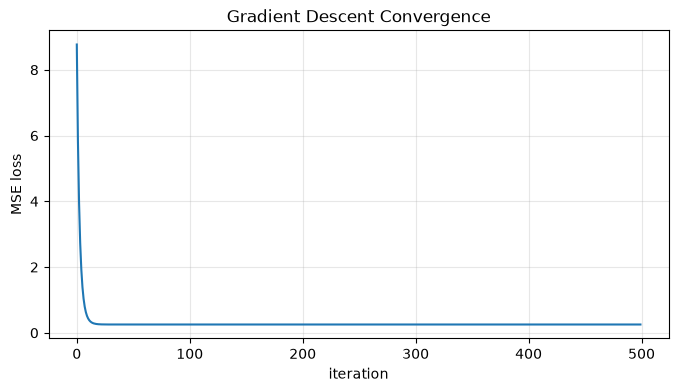

Loss: 8.7694 -> 0.2531


In [4]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("iteration")
plt.ylabel("MSE loss")
plt.title("Gradient Descent Convergence")
plt.grid(True, alpha=0.3)
plt.show()
print(f"Loss: {loss_history[0]:.4f} -> {loss_history[-1]:.4f}")


## 10. Step 5: Evaluate with Statistics (Probability)

From Unit 02.5, we evaluate the model using statistical measures: residuals, R-squared, and the assumption that residuals are normally distributed.


R-squared: 0.9772 (fraction of variance explained)
Mean residual: -0.0000 (should be ~0)
Residual std: 0.5031 (matches noise 0.5)



Shapiro-Wilk normality test p-value: 0.9009
Residuals look normal (p > 0.05): True


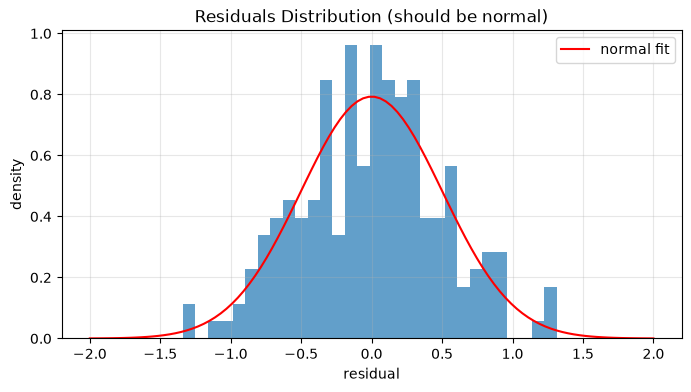

In [5]:
# Evaluate the model
pred = X_b @ w
residuals = y - pred

# R-squared: fraction of variance explained
ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"R-squared: {r2:.4f} (fraction of variance explained)")
print(f"Mean residual: {np.mean(residuals):.4f} (should be ~0)")
print(f"Residual std: {np.std(residuals):.4f} (matches noise 0.5)")

# Check residuals are roughly normal (from Unit 02.5)
from scipy import stats
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"\nShapiro-Wilk normality test p-value: {shapiro_p:.4f}")
print(f"Residuals look normal (p > 0.05): {shapiro_p > 0.05}")

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=30, density=True, alpha=0.7)
x = np.linspace(-2, 2, 100)
plt.plot(x, stats.norm.pdf(x, 0, np.std(residuals)), "r-", label="normal fit")
plt.xlabel("residual")
plt.ylabel("density")
plt.title("Residuals Distribution (should be normal)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 11. Step 6: Likelihood and Cross-Entropy (Information Theory)

From Unit 02.6, minimizing MSE is equivalent to maximizing the **likelihood** of the data under a Gaussian noise model. The connection: assuming Gaussian noise, maximizing log-likelihood is equivalent to minimizing MSE. This is the information-theoretic justification for the loss.


In [6]:
# Connection between MSE and Gaussian log-likelihood
# Under Gaussian noise, log-likelihood = -n/2 * log(2*pi*sigma^2) - (1/(2*sigma^2)) * sum(residual^2)
# Maximizing log-likelihood == minimizing sum(residual^2) == minimizing MSE
sigma = np.std(residuals)
log_likelihood = -n/2 * np.log(2 * np.pi * sigma**2) - (1 / (2 * sigma**2)) * np.sum(residuals**2)

print(f"Estimated noise sigma: {sigma:.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print("\nMinimizing MSE == maximizing Gaussian log-likelihood.")
print("This is why MSE is the right loss when noise is Gaussian.")


Estimated noise sigma: 0.5031
Log-likelihood: -146.4038

Minimizing MSE == maximizing Gaussian log-likelihood.
This is why MSE is the right loss when noise is Gaussian.


## 12. Step 7: PCA Dimensionality Reduction (Eigenvalues)

From Unit 02.7, we use **PCA** to reduce the dimensionality of a higher-dimensional dataset, keeping the directions of greatest variance (largest eigenvalues).


In [7]:
# PCA on a higher-dimensional dataset
np.random.seed(7)
n_high = 300
X_high = np.random.randn(n_high, 5)
# Make some features correlated (redundant)
X_high[:, 1] = 0.95 * X_high[:, 0] + 0.1 * np.random.randn(n_high)
X_high[:, 3] = 0.9 * X_high[:, 2] + 0.1 * np.random.randn(n_high)

# Center the data
mean = np.mean(X_high, axis=0)
centered = X_high - mean

# Covariance matrix and eigenvalues (Unit 02.7)
cov = np.cov(centered.T)
eigenvalues, eigenvectors = np.linalg.eigh(cov)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

explained = eigenvalues / np.sum(eigenvalues)
print("Eigenvalues (sorted):", np.round(eigenvalues, 4))
print("Fraction of variance explained:", np.round(explained, 4))
print(f"\nTop 2 components explain {np.sum(explained[:2]):.1%} of variance")
print("We can reduce 5 dimensions to 2 while keeping most information.")

# Project to 2D
W = eigenvectors[:, :2]
X_2d = centered @ W
print(f"\nReduced shape: {X_2d.shape} (from {X_high.shape})")


Eigenvalues (sorted): [1.9997 1.5417 0.9304 0.0058 0.0052]
Fraction of variance explained: [0.4461 0.3439 0.2076 0.0013 0.0012]

Top 2 components explain 79.0% of variance
We can reduce 5 dimensions to 2 while keeping most information.

Reduced shape: (300, 2) (from (300, 5))


## 13. Step 8: Visualize the Reduced Data

Let's visualize the 5D data projected into 2D via PCA.


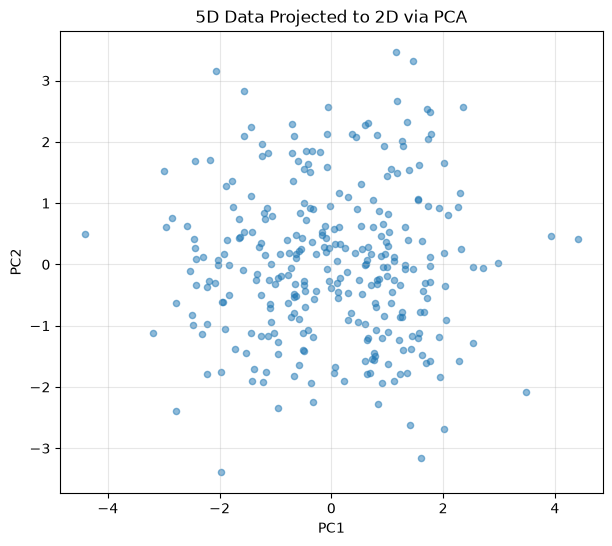

The 2D projection captures the dominant structure of the 5D data.


In [8]:
plt.figure(figsize=(7, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, s=20)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("5D Data Projected to 2D via PCA")
plt.grid(True, alpha=0.3)
plt.show()
print("The 2D projection captures the dominant structure of the 5D data.")


## 14. Failure Case: Overfitting

A key risk when combining all these tools: using too many features (or too complex a model) leads to **overfitting** - the model fits noise, not signal. This connects to the bias-variance tradeoff.


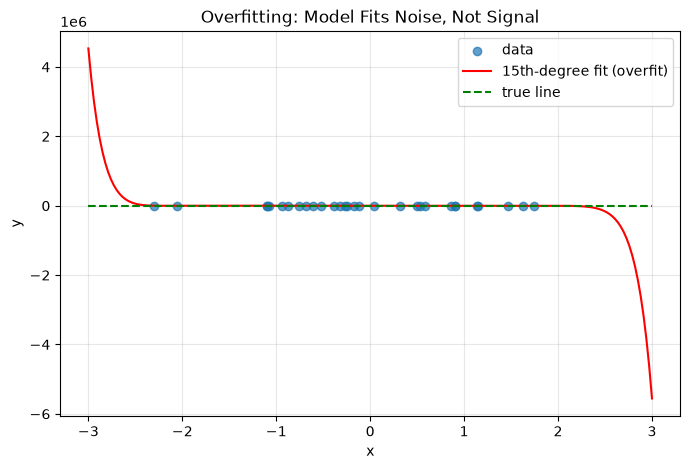

The 15th-degree polynomial wiggles wildly to fit every point - it generalizes poorly.


In [9]:
# Overfitting: too many features
np.random.seed(1)
n_small = 30
X_small = np.random.randn(n_small, 1)
y_small = 2 * X_small[:, 0] + 1 + np.random.randn(n_small) * 0.3

# Fit a high-degree polynomial (too many parameters)
from numpy.polynomial import polynomial as P
coeffs = np.polyfit(X_small[:, 0], y_small, 15)  # 15th degree on 30 points

x_line = np.linspace(-3, 3, 200)
y_line = np.polyval(coeffs, x_line)

plt.figure(figsize=(8, 5))
plt.scatter(X_small[:, 0], y_small, alpha=0.7, label="data")
plt.plot(x_line, y_line, "r-", label="15th-degree fit (overfit)")
plt.plot(x_line, 2 * x_line + 1, "g--", label="true line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Overfitting: Model Fits Noise, Not Signal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("The 15th-degree polynomial wiggles wildly to fit every point - it generalizes poorly.")


## 15. Debugging: Common Errors

- **Matrix shape mismatches**: `X @ w` requires compatible dimensions. Check shapes with `.shape`.
- **Singular matrix in normal equation**: if `X^T X` is not invertible, use gradient descent or add regularization.
- **Learning rate too high**: gradient descent diverges (loss explodes).
- **Not centering data before PCA**: PCA requires centered data.
- **Overfitting**: too many parameters relative to data. Use fewer features or regularization.

## 16. Real-World Considerations

- **Regularization** (Ridge/Lasso) adds a penalty to prevent overfitting and handle singular matrices.
- **Feature scaling** is critical for gradient descent to converge quickly.
- **Cross-validation** estimates how well the model generalizes to new data.
- **PCA** is used for visualization, denoising, and speeding up training.
- **The full pipeline** (data -> model -> train -> evaluate -> reduce) is the template for every ML project.

## 17. Common Mistakes

- Forgetting to add a bias term (column of ones).
- Not scaling features before gradient descent.
- Using too many features and overfitting.
- Interpreting R-squared as causation.
- Not checking residuals for normality.

## 18. When NOT to Use

- Don't use the normal equation for very large datasets (inverting a huge matrix is expensive) - use gradient descent.
- Don't use PCA when you need to keep original feature interpretability.
- Don't use linear regression when the relationship is clearly non-linear.

## 19. Challenge

Train a linear regression model on the 3-feature dataset using **mini-batch gradient descent** (from Unit 02.4), and report the final R-squared. Verify it's close to the full-batch result.


In [10]:
# Challenge: mini-batch gradient descent
np.random.seed(99)
w_mb = np.zeros(4)
lr = 0.1
batch_size = 16
n_epochs = 50

for epoch in range(n_epochs):
    idx = np.random.permutation(n)
    for start in range(0, n, batch_size):
        end = start + batch_size
        Xb = X_b[idx[start:end]]
        yb = y[idx[start:end]]
        pred = Xb @ w_mb
        grad = (2 / len(Xb)) * Xb.T @ (pred - yb)
        w_mb = w_mb - lr * grad

pred_mb = X_b @ w_mb
r2_mb = 1 - np.sum((y - pred_mb) ** 2) / np.sum((y - np.mean(y)) ** 2)

print("Mini-batch gradient descent:")
print(f"  w: {np.round(w_mb, 4)}")
print(f"  R-squared: {r2_mb:.4f} (full-batch was {r2:.4f})")
print(f"  Close to full-batch: {abs(r2_mb - r2) < 0.01}")


Mini-batch gradient descent:
  w: [ 0.9916  2.9598 -2.0403  0.5431]
  R-squared: 0.9764 (full-batch was 0.9772)
  Close to full-batch: True


## Hands-On Practice

### Level 1: Basic
- Review: compute dot products, matrix multiplications, derivatives by hand

### Level 2: Guided
- Derive the gradient of a loss function and implement gradient descent

### Level 3: Independent
- Implement linear regression from scratch using only NumPy

### Level 4: Realistic
- Build a PCA pipeline from scratch and compare with sklearn

### Level 5: Challenge
- Derive and implement the backpropagation equations for a 2-layer network


## Knowledge Check

1. Explain the chain rule and why it matters for backpropagation.
2. What is the geometric interpretation of eigenvalues?
3. How does gradient descent use calculus to minimize a loss function?



## Exit Criteria

- [ ] Can apply linear algebra, calculus, probability, and information theory to ML problems
- [ ] Can implement gradient descent from scratch
- [ ] Can use PCA for dimensionality reduction
- [ ] Completed Level 4+ practice



## Next Step

-> Phase 03: Statistics and Probability — the foundation of ML inference.


## 20. Closed-Book Recall

Without looking back:

1. Write the normal equation.
2. Write the gradient descent update rule.
3. What does R-squared measure?
4. Why is minimizing MSE equivalent to maximizing Gaussian likelihood?
5. How does PCA use eigenvalues to reduce dimensionality?

## 21. Teach-Back Questions

Explain to another person:

- How do vectors, matrices, gradients, and gradient descent combine to train a model?
- Why does the normal equation give the same answer as gradient descent?
- How does PCA reduce dimensions while keeping the most information?

## 22. Summary

You have now built a complete model from scratch using every Phase 02 concept: vectors and matrices for data representation, the normal equation and gradient descent for training, statistics for evaluation, information theory for understanding the loss, and PCA for dimensionality reduction. This is the mathematical foundation of all of machine learning.

## 23. Further Experiment

- Add L2 regularization (Ridge) to the gradient descent and observe the effect.
- Apply the full pipeline to a real dataset (e.g. from sklearn).
- Implement logistic regression using the same math, with cross-entropy loss.

## 24. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, matplotlib, scipy
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```
